Q Develop a simple expert system using rule-based reasoning/fuzzy logic.
Example 1 :


--------------------------------
COMPLETE MEDICAL EXPERT SYSTEM

Please answer the following questions (y/n):

--------------------
DIAGNOSIS REPORT

Found 3 possible conditions:

1. Influenza:
   Match: 100.0%
   Urgency: medium (50.0/100)

   Symptoms present:
   ✓ fever
   ✓ cough
   ✓ fatigue
   ✓ body ache
   ✓ headache

   Recommended treatments:
   • Antiviral (Tamiflu)
   • Rest
   • Fluids
   • Pain relievers

   Reasoning: Has fever; Has cough; Has fatigue...
----------------------------------------

2. COVID-19:
   Match: 83.3%
   Urgency: high (50.0/100)

   Symptoms present:
   ✓ fever
   ✓ cough
   ✓ shortness of breath
   ✓ loss of taste
   ✓ fatigue

   Recommended treatments:
   • Isolation
   • Medical consultation
   • Symptomatic treatment

   Reasoning: Has fever; Has cough; Has shortness of breath...
----------------------------------------

3. Common Cold:
   Match: 40.0%
   Urgency: low (50.0/100)

   Symptoms present:
   ✓ runny nose
   ✓ cough

   Recommended

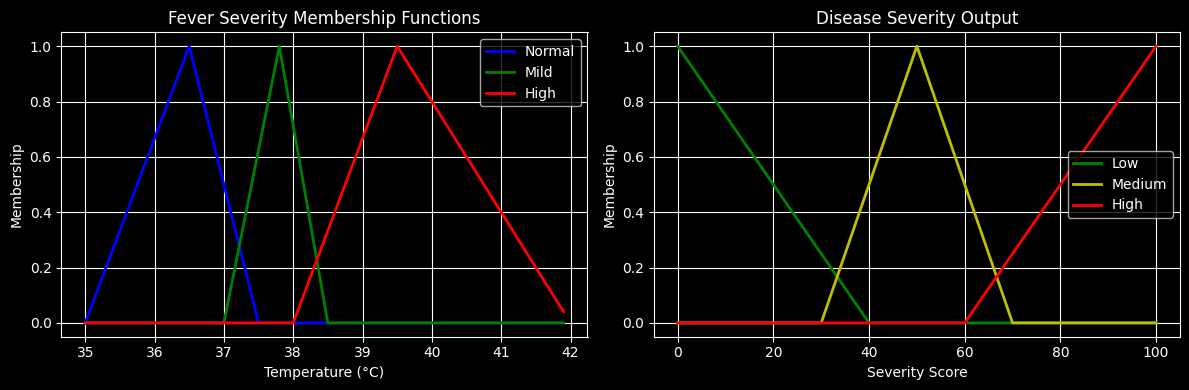

In [9]:
"""
MEDICAL EXPERT SYSTEM
Multiple diseases with explanation and visualization
"""

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

class CompleteMedicalExpert:
    """Comprehensive medical diagnosis system"""

    def __init__(self):
        self.diseases = self._load_disease_database()
        self.fuzzy_ctrls = self._setup_fuzzy_controls()
        self.patient_history = []

    def _load_disease_database(self):
        """Comprehensive disease knowledge base"""
        return {
            'Influenza': {
                'symptoms': ['fever', 'cough', 'fatigue', 'body_ache', 'headache'],
                'required': ['fever', 'cough'],
                'risk_factors': ['elderly', 'chronic_illness', 'pregnancy'],
                'treatments': ['Antiviral (Tamiflu)', 'Rest', 'Fluids', 'Pain relievers'],
                'urgency': 'medium'
            },
            'Common Cold': {
                'symptoms': ['runny_nose', 'sneezing', 'sore_throat', 'cough', 'mild_fever'],
                'required': ['runny_nose'],
                'risk_factors': [],
                'treatments': ['Rest', 'Antihistamines', 'Nasal decongestant'],
                'urgency': 'low'
            },
            'COVID-19': {
                'symptoms': ['fever', 'cough', 'shortness_of_breath', 'loss_of_taste',
                           'loss_of_smell', 'fatigue'],
                'required': ['fever', 'cough'],
                'risk_factors': ['elderly', 'diabetes', 'heart_disease', 'obesity'],
                'treatments': ['Isolation', 'Medical consultation', 'Symptomatic treatment'],
                'urgency': 'high'
            },
            'Pneumonia': {
                'symptoms': ['high_fever', 'cough_with_phlegm', 'chest_pain',
                           'shortness_of_breath', 'fatigue'],
                'required': ['high_fever', 'cough_with_phlegm'],
                'risk_factors': ['smoking', 'lung_disease', 'weak_immune'],
                'treatments': ['Antibiotics', 'Hospitalization', 'Oxygen therapy'],
                'urgency': 'high'
            }
        }

    def _setup_fuzzy_controls(self):
        """Setup multiple fuzzy controllers"""
        controllers = {}

        # Fever severity controller
        fever = ctrl.Antecedent(np.arange(35, 42, 0.1), 'fever')
        fever['normal'] = fuzz.trimf(fever.universe, [35, 36.5, 37.5])
        fever['mild'] = fuzz.trimf(fever.universe, [37, 37.8, 38.5])
        fever['high'] = fuzz.trimf(fever.universe, [38, 39.5, 42])

        severity = ctrl.Consequent(np.arange(0, 101, 1), 'severity')
        severity['low'] = fuzz.trimf(severity.universe, [0, 0, 40])
        severity['medium'] = fuzz.trimf(severity.universe, [30, 50, 70])
        severity['high'] = fuzz.trimf(severity.universe, [60, 100, 100])

        rules = [
            ctrl.Rule(fever['high'], severity['high']),
            ctrl.Rule(fever['mild'], severity['medium']),
            ctrl.Rule(fever['normal'], severity['low'])
        ]

        controllers['fever'] = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
        return controllers

    def interactive_diagnosis(self):
        """Interactive diagnosis session"""
        print("\n--------------------------------")
        print("COMPLETE MEDICAL EXPERT SYSTEM")


        # Collect symptoms
        symptoms = self._collect_symptoms()

        # Analyze
        results = self._analyze_symptoms(symptoms)

        # Generate report
        self._generate_report(results, symptoms)

        # Visualize if requested
        self._visualize_fuzzy_sets()

    def _collect_symptoms(self):
        """Interactive symptom collection"""
        symptoms = {}

        print("\nPlease answer the following questions (y/n):")

        questions = [
            ('fever', 'Do you have fever? If yes, enter temperature (e.g., 38.5): '),
            ('cough', 'Do you have cough? Rate severity 0-10: '),
            ('fatigue', 'Do you feel fatigued? '),
            ('runny_nose', 'Do you have runny nose? '),
            ('shortness_of_breath', 'Do you have shortness of breath? '),
            ('loss_of_taste', 'Have you lost sense of taste? '),
            ('body_ache', 'Do you have body aches? '),
            ('headache', 'Do you have headache? ')
        ]

        for symptom, question in questions:
            response = input(f"\n{question}").strip().lower()
            if response in ['y', 'yes', 'true']:
                symptoms[symptom] = True
            elif symptom == 'fever' and response.replace('.', '').isdigit():
                symptoms['fever'] = True
                symptoms['fever_temp'] = float(response)
            elif symptom == 'cough' and response.isdigit():
                symptoms['cough'] = True
                symptoms['cough_level'] = int(response)
            elif response in ['n', 'no', 'false']:
                symptoms[symptom] = False

        return symptoms

    def _analyze_symptoms(self, symptoms):
        """Analyze symptoms against disease database"""
        results = []

        for disease, data in self.diseases.items():
            score = 0
            matched_symptoms = []
            explanation = []

            # Check required symptoms
            has_required = all(symptom in symptoms and symptoms[symptom]
                             for symptom in data['required'])

            if not has_required:
                continue

            # Calculate matching score
            for symptom in data['symptoms']:
                if symptom in symptoms and symptoms[symptom]:
                    score += 1
                    matched_symptoms.append(symptom)
                    explanation.append(f"Has {symptom.replace('_', ' ')}")

            # Calculate percentage match
            match_percent = (score / len(data['symptoms'])) * 100

            # Assess urgency with fuzzy logic
            urgency_score = self._assess_urgency(symptoms, disease)

            results.append({
                'disease': disease,
                'match_percent': match_percent,
                'matched_symptoms': matched_symptoms,
                'explanation': explanation,
                'treatments': data['treatments'],
                'urgency': data['urgency'],
                'urgency_score': urgency_score
            })

        return sorted(results, key=lambda x: x['match_percent'], reverse=True)

    def _assess_urgency(self, symptoms, disease):
        """Fuzzy logic urgency assessment"""
        if 'fever_temp' in symptoms and disease in self.fuzzy_ctrls:
            ctrl = self.fuzzy_ctrls['fever']
            ctrl.input['fever'] = symptoms['fever_temp']
            ctrl.compute()
            return ctrl.output['severity']
        return 50  # Default medium

    def _generate_report(self, results, symptoms):
        """Generate comprehensive diagnosis report"""
        print("\n--------------------")
        print("DIAGNOSIS REPORT")


        if not results:
            print("\nNo matching diseases found.")
            print("Recommendation: Consult a doctor for accurate diagnosis.")
            return

        print(f"\nFound {len(results)} possible conditions:")

        for i, result in enumerate(results[:3], 1):  # Top 3
            print(f"\n{i}. {result['disease']}:")
            print(f"   Match: {result['match_percent']:.1f}%")
            print(f"   Urgency: {result['urgency']} ({result['urgency_score']:.1f}/100)")

            print(f"\n   Symptoms present:")
            for symptom in result['matched_symptoms'][:5]:  # Show top 5
                print(f"   ✓ {symptom.replace('_', ' ')}")

            print(f"\n   Recommended treatments:")
            for treatment in result['treatments']:
                print(f"   • {treatment}")

            print(f"\n   Reasoning: {'; '.join(result['explanation'][:3])}...")
            print("-"*40)

    def _visualize_fuzzy_sets(self):
        """Visualize fuzzy membership functions"""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Fever membership visualization
        fever = np.arange(35, 42, 0.1)
        normal = fuzz.trimf(fever, [35, 36.5, 37.5])
        mild = fuzz.trimf(fever, [37, 37.8, 38.5])
        high = fuzz.trimf(fever, [38, 39.5, 42])

        axes[0].plot(fever, normal, 'b', linewidth=2, label='Normal')
        axes[0].plot(fever, mild, 'g', linewidth=2, label='Mild')
        axes[0].plot(fever, high, 'r', linewidth=2, label='High')
        axes[0].set_title('Fever Severity Membership Functions')
        axes[0].set_xlabel('Temperature (°C)')
        axes[0].set_ylabel('Membership')
        axes[0].legend()
        axes[0].grid(True)

        # Severity output visualization
        severity = np.arange(0, 101, 1)
        low = fuzz.trimf(severity, [0, 0, 40])
        medium = fuzz.trimf(severity, [30, 50, 70])
        high_sev = fuzz.trimf(severity, [60, 100, 100])

        axes[1].plot(severity, low, 'g', linewidth=2, label='Low')
        axes[1].plot(severity, medium, 'y', linewidth=2, label='Medium')
        axes[1].plot(severity, high_sev, 'r', linewidth=2, label='High')
        axes[1].set_title('Disease Severity Output')
        axes[1].set_xlabel('Severity Score')
        axes[1].set_ylabel('Membership')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.savefig('fuzzy_visualization.png', dpi=150)
        print("\n✓ Fuzzy sets visualization saved as 'fuzzy_visualization.png'")

# Example usage
def run_system_b():
    """Demo of Complete Medical System"""
    expert = CompleteMedicalExpert()
    expert.interactive_diagnosis()

if __name__ == "__main__":
    run_system_b()



Example 2 :

In [11]:

"""
INTERACTIVE CAR DIAGNOSTIC EXPERT SYSTEM
Interactive version that asks user questions
"""

class InteractiveCarDiagnosticExpert:
    """Interactive car trouble diagnosis system with user input"""

    def __init__(self):
        self.rules = self._initialize_rules()
        self.questions = self._initialize_questions()
        self.certainty_factors = {}
        self.symptoms = {}

    def _initialize_rules(self):
        """Rule-based knowledge for car diagnostics"""
        return [
            {
                'id': 'R1',
                'if': ['engine_wont_start', 'no_sound'],
                'then': 'Starter motor problem',
                'cf': 0.8,
                'action': 'Check starter motor and battery connections',
                'cost_estimate': 'RS 2000-5000'
            },
            {
                'id': 'R2',
                'if': ['engine_wont_start', 'clicking_sound'],
                'then': 'Weak battery',
                'cf': 0.9,
                'action': 'Jump start or replace battery',
                'cost_estimate': 'RS 3000-8000'
            },
            {
                'id': 'R3',
                'if': ['engine_wont_start', 'cranks_but_no_start'],
                'then': 'Fuel system problem',
                'cf': 0.7,
                'action': 'Check fuel pump and fuel filter',
                'cost_estimate': 'RS 1500-4000'
            },
            {
                'id': 'R4',
                'if': ['engine_stalls', 'rough_idle'],
                'then': 'Spark plug issue',
                'cf': 0.6,
                'action': 'Replace spark plugs',
                'cost_estimate': 'RS 1000-3000'
            },
            {
                'id': 'R5',
                'if': ['poor_acceleration', 'high_fuel_consumption'],
                'then': 'Clogged air filter',
                'cf': 0.7,
                'action': 'Clean or replace air filter',
                'cost_estimate': 'RS 500-1500'
            },
            {
                'id': 'R6',
                'if': ['overheating', 'coolant_leak'],
                'then': 'Cooling system failure',
                'cf': 0.85,
                'action': 'Check radiator and coolant levels',
                'cost_estimate': 'RS 2500-6000'
            },
            {
                'id': 'R7',
                'if': ['brake_noise', 'vibration_while_braking'],
                'then': 'Worn brake pads',
                'cf': 0.75,
                'action': 'Replace brake pads immediately',
                'cost_estimate': 'RS 2000-4000'
            },
            {
                'id': 'R8',
                'if': ['check_engine_light', 'poor_performance'],
                'then': 'Sensor malfunction',
                'cf': 0.65,
                'action': 'Diagnose with OBD-II scanner',
                'cost_estimate': 'RS 1000-5000'
            },
            {
                'id': 'R9',
                'if': ['steering_vibration', 'uneven_tire_wear'],
                'then': 'Wheel alignment needed',
                'cf': 0.8,
                'action': 'Get wheel alignment and balancing',
                'cost_estimate': 'RS 800-2000'
            },
            {
                'id': 'R10',
                'if': ['loud_exhaust', 'decreased_power'],
                'then': 'Exhaust system leak',
                'cf': 0.7,
                'action': 'Check exhaust manifold and pipes',
                'cost_estimate': 'RS 3000-10000'
            }
        ]

    def _initialize_questions(self):
        """Interactive questions with descriptions"""
        return [
            {
                'id': 'engine_wont_start',
                'question': "Does the engine not start at all?",
                'options': ['Yes', 'No'],
                'hint': "Engine doesn't turn over when you turn the key"
            },
            {
                'id': 'no_sound',
                'question': "Is there NO sound when turning the key?",
                'options': ['Yes', 'No'],
                'hint': "Complete silence, no clicking or cranking"
            },
            {
                'id': 'clicking_sound',
                'question': "Do you hear a clicking sound when trying to start?",
                'options': ['Yes', 'No'],
                'hint': "Rapid clicking noise from engine compartment"
            },
            {
                'id': 'cranks_but_no_start',
                'question': "Does it crank but not start?",
                'options': ['Yes', 'No'],
                'hint': "Engine turns over but doesn't fire up"
            },
            {
                'id': 'engine_stalls',
                'question': "Does the engine stall frequently?",
                'options': ['Yes', 'No'],
                'hint': "Engine dies while idling or driving"
            },
            {
                'id': 'rough_idle',
                'question': "Is the idle rough or uneven?",
                'options': ['Yes', 'No'],
                'hint': "Engine shakes or RPM fluctuates at stop"
            },
            {
                'id': 'poor_acceleration',
                'question': "Is acceleration poor or sluggish?",
                'options': ['Yes', 'No'],
                'hint': "Car feels slow to respond when accelerating"
            },
            {
                'id': 'high_fuel_consumption',
                'question': "Is fuel consumption higher than usual?",
                'options': ['Yes', 'No'],
                'hint': "More frequent trips to gas station"
            },
            {
                'id': 'overheating',
                'question': "Is the engine overheating?",
                'options': ['Yes', 'No'],
                'hint': "Temperature gauge in red zone"
            },
            {
                'id': 'coolant_leak',
                'question': "Do you see coolant leaks under the car?",
                'options': ['Yes', 'No'],
                'hint': "Green/colored puddle under parked car"
            },
            {
                'id': 'brake_noise',
                'question': "Do you hear noise when braking?",
                'options': ['Yes', 'No'],
                'hint': "Squealing, grinding, or scraping sounds"
            },
            {
                'id': 'vibration_while_braking',
                'question': "Do you feel vibration when braking?",
                'options': ['Yes', 'No'],
                'hint': "Steering wheel or pedal shakes during braking"
            },
            {
                'id': 'check_engine_light',
                'question': "Is the check engine light ON?",
                'options': ['Yes', 'No'],
                'hint': "Orange/yellow engine symbol on dashboard"
            },
            {
                'id': 'poor_performance',
                'question': "Is overall performance poor?",
                'options': ['Yes', 'No'],
                'hint': "General lack of power or responsiveness"
            },
            {
                'id': 'steering_vibration',
                'question': "Do you feel vibration in steering wheel?",
                'options': ['Yes', 'No'],
                'hint': "Steering wheel shakes at certain speeds"
            },
            {
                'id': 'uneven_tire_wear',
                'question': "Are tires wearing unevenly?",
                'options': ['Yes', 'No'],
                'hint': "One side of tire more worn than other"
            },
            {
                'id': 'loud_exhaust',
                'question': "Is exhaust louder than normal?",
                'options': ['Yes', 'No'],
                'hint': "Unusual rumbling or roaring from exhaust"
            },
            {
                'id': 'decreased_power',
                'question': "Has engine power decreased?",
                'options': ['Yes', 'No'],
                'hint': "Car struggles on hills or with load"
            }
        ]

    def start_diagnosis(self):
        """Main interactive diagnosis procedure"""
        print("\n------------")
        print("INTERACTIVE CAR DIAGNOSTIC EXPERT SYSTEM")

        print("\nWelcome! I'll help diagnose your car problems.")
        print("Please answer the following questions about your car's symptoms.\n")

        # Collect car information
        self._collect_car_info()

        # Collect symptoms interactively
        self._collect_symptoms_interactive()

        # Apply rules and diagnose
        diagnoses = self._apply_rules()

        # Generate report
        self._generate_report(diagnoses)

        # Ask if user wants explanation
        self._offer_explanation()

        # Ask about repair
        self._offer_repair_advice()

    def _collect_car_info(self):
        """Collect basic car information"""
        print("First, let's get some basic information:")


        self.car_info = {}

        self.car_info['make'] = input("Car make (e.g., Toyota, Honda): ").strip()
        self.car_info['model'] = input("Car model (e.g., Corolla, Civic): ").strip()
        self.car_info['year'] = input("Year of manufacture: ").strip()
        self.car_info['mileage'] = input("Current mileage (km): ").strip()

        print("\nThanks! Now let's talk about the problems you're experiencing.\n")

    def _collect_symptoms_interactive(self):
        """Interactive symptom collection with user-friendly interface"""
        print("Please describe your car's symptoms:")


        symptoms_collected = 0

        for i, q in enumerate(self.questions, 1):
            print(f"\n{i}: {q['question']}")
            if q.get('hint'):
                print(f"{q['hint']}")

            # Get user response
            while True:
                response = input(f" Enter {q['options'][0]}/{q['options'][1]}: ").strip().lower()

                if response in ['yes', 'y', 'true', '1']:
                    self.symptoms[q['id']] = True
                    symptoms_collected += 1
                    break
                elif response in ['no', 'n', 'false', '0']:
                    self.symptoms[q['id']] = False
                    break
                else:
                    print(f"   Please enter '{q['options'][0]}' or '{q['options'][1]}'")

        print(f"\n✓ Collected {symptoms_collected} symptoms")

    def _apply_rules(self):
        """Apply rule-based reasoning to symptoms"""
        diagnoses = []
        self.certainty_factors = {}

        print("\n" + "Analyzing symptoms...")


        for rule in self.rules:
            # Check if all conditions are met
            conditions_met = all(self.symptoms.get(cond, False) for cond in rule['if'])

            if conditions_met:
                cf = rule['cf']
                problem = rule['then']

                # Print which rule fired
                conditions_str = ' AND '.join(rule['if']).replace('_', ' ')
                print(f"Rule {rule['id']} fired: IF {conditions_str}")
                print(f"  Diagnosis: {problem} (CF={cf})")

                if problem in self.certainty_factors:
                    # Combine certainty factors
                    old_cf = self.certainty_factors[problem]['cf']
                    new_cf = old_cf + cf - (old_cf * cf)
                    self.certainty_factors[problem] = {
                        'cf': new_cf,
                        'rules': self.certainty_factors[problem]['rules'] + [rule['id']],
                        'action': rule['action'],
                        'cost': rule['cost_estimate']
                    }
                else:
                    self.certainty_factors[problem] = {
                        'cf': cf,
                        'rules': [rule['id']],
                        'action': rule['action'],
                        'cost': rule['cost_estimate']
                    }

                diagnoses.append({
                    'problem': problem,
                    'certainty': cf,
                    'action': rule['action'],
                    'cost': rule['cost_estimate'],
                    'rule': rule['id']
                })

        return sorted(diagnoses, key=lambda x: x['certainty'], reverse=True)

    def _generate_report(self, diagnoses):
        """Generate comprehensive diagnostic report"""

        print("DIAGNOSTIC REPORT")


        # Car info summary
        print(f"\nCar: {self.car_info.get('make', 'Unknown')} {self.car_info.get('model', 'Unknown')}")
        print(f"Year: {self.car_info.get('year', 'Unknown')}")
        print(f"Mileage: {self.car_info.get('mileage', 'Unknown')} km")

        # Symptom summary
        symptom_count = sum(1 for s in self.symptoms.values() if s)
        print(f"\nSymptoms reported: {symptom_count}/18")

        if not diagnoses:
            print("\n-----------")
            print("No specific problems identified.")
            print("\nRecommendations:")
            print("1. Basic maintenance check")
            print("2. Oil change if due")
            print("3. Tire pressure check")
            return

        print(f"\nProblems identified: {len(diagnoses)}")
        print("\n-------------")

        # Show top diagnoses
        for i, diag in enumerate(diagnoses[:3], 1):
            problem = diag['problem']
            cf_data = self.certainty_factors.get(problem, {})
            certainty = cf_data.get('cf', diag['certainty']) * 100

            # Determine severity
            if certainty > 80:
                severity = "HIGH"
            elif certainty > 50:
                severity = "MEDIUM"
            else:
                severity = "LOW"

            print(f"\n{i}. {problem.upper()}")
            print(f"   Confidence: {certainty:.1f}%")
            print(f"   Severity: {severity}")
            print(f"   Action: {diag['action']}")
            print(f"   Estimated Cost: {diag['cost']}")

            # Show contributing symptoms
            rule_ids = cf_data.get('rules', [diag['rule']])
            for rule_id in rule_ids[:2]:  # Show up to 2 rules
                rule = next((r for r in self.rules if r['id'] == rule_id), None)
                if rule:
                    conditions = ' AND '.join(rule['if']).replace('_', ' ')
                    print(f"   Reason: {conditions}")

        # Overall assessment
        print("\n---------")
        if diagnoses[0]['certainty'] > 0.7:
            print("URGENT ATTENTION REQUIRED!")
            print("• Safety may be compromised")
            print("• Repair immediately")
        elif diagnoses[0]['certainty'] > 0.4:
            print("SCHEDULE REPAIR SOON")
            print("• Problem detected")
            print("• Schedule within 1-2 weeks")
        else:
            print("MONITOR AND MAINTAIN")
            print("• Minor issue detected")
            print("• Address during next service")

    def _offer_explanation(self):
        """Offer to explain reasoning"""
        if not self.certainty_factors:
            return

        response = input("\n Would you like to see detailed reasoning? (yes/no): ").lower()

        if response in ['yes', 'y']:
            print("\n------------")
            print("REASONING EXPLANATION")


            for problem, data in self.certainty_factors.items():
                print(f"\nFor '{problem}':")
                print(f"  Final Confidence: {data['cf']*100:.1f}%")

                # Show all contributing rules
                for rule_id in data['rules']:
                    rule = next((r for r in self.rules if r['id'] == rule_id), None)
                    if rule:
                        conditions = ' AND '.join(rule['if']).replace('_', ' ')
                        print(f"  • Rule {rule_id}: IF {conditions}")
                        print(f"      THEN {rule['then']} (CF={rule['cf']})")

                print(f"  Recommended Action: {data['action']}")
                print(f"  Estimated Cost: {data['cost']}")

    def _offer_repair_advice(self):
        """Offer repair and maintenance advice"""
        response = input("\nWould you like general car maintenance advice? (yes/no): ").lower()

        if response in ['yes', 'y']:

            print("GENERAL CAR MAINTENANCE ADVICE")


            mileage = int(self.car_info.get('mileage', 0)) if self.car_info.get('mileage', '').isdigit() else 0

            print("\nBased on your car's information:")

            if mileage > 100000:
                print("HIGH MILEAGE (>100,000 km):")
                print("  - Check timing belt/chain replacement")
                print("  - Inspect suspension components")
                print("  - Consider transmission fluid change")
            elif mileage > 50000:
                print("MEDIUM MILEAGE (50,000-100,000 km):")
                print("  - Change coolant and brake fluid")
                print("  - Inspect brakes and tires")
                print("  - Check battery health")
            else:
                print("•LOW MILEAGE (<50,000 km):")
                print("  - Regular oil changes")
                print("  - Check tire pressure monthly")
                print("  - Keep up with scheduled maintenance")

            # Specific advice based on symptoms
            if self.symptoms.get('high_fuel_consumption', False):
                print("\nFOR FUEL EFFICIENCY:")
                print("  - Check tire pressure (low pressure increases fuel use)")
                print("  - Clean air filter")
                print("  - Use recommended fuel grade")

            if self.symptoms.get('brake_noise', False) or self.symptoms.get('vibration_while_braking', False):
                print("\nBRAKE SAFETY:")
                print("  - Brakes are critical for safety")
                print("  - Don't delay brake repairs")
                print("  - Get professional inspection")

    def run_quick_test(self):
        """Quick diagnostic test for common problems"""

        print("QUICK DIAGNOSTIC TEST")

        print("\nAnswer 3 key questions for quick assessment:\n")

        quick_questions = [
            ("engine_wont_start", "Does the engine not start?"),
            ("check_engine_light", "Is check engine light ON?"),
            ("brake_noise", "Any brake noise or issues?")
        ]

        quick_symptoms = {}
        for symptom_id, question in quick_questions:
            response = input(f"{question} (yes/no): ").lower()
            quick_symptoms[symptom_id] = response in ['yes', 'y']

        # Quick analysis
        print("\n---------------")
        print("QUICK ASSESSMENT:")

        if quick_symptoms.get('engine_wont_start'):
            print("Starting problem detected")
            print("  - Check battery and starter")
        if quick_symptoms.get('check_engine_light'):
            print("Check engine light ON")
            print("  - Get OBD-II diagnostic scan")
        if quick_symptoms.get('brake_noise'):
            print("Brake issue detected")
            print("  - Immediate inspection recommended")

        if not any(quick_symptoms.values()):
            print("• No major issues detected in quick test")
            print("  - Continue with full diagnosis if problems persist")

# Main execution
def run_interactive_car_diagnostic():
    """Run the interactive car diagnostic system"""
    expert = InteractiveCarDiagnosticExpert()


    print("SELECT DIAGNOSTIC MODE:")

    print("1. Full Interactive Diagnosis")
    print("2. Quick Diagnostic Test")
    print("3. Exit")

    choice = input("\nEnter choice (1-3): ").strip()

    if choice == '1':
        expert.start_diagnosis()
    elif choice == '2':
        expert.run_quick_test()
        # Ask if they want full diagnosis after quick test
        response = input("\nRun full diagnosis? (yes/no): ").lower()
        if response in ['yes', 'y']:
            expert.start_diagnosis()
    elif choice == '3':
        print("\nThank you for using Car Diagnostic Expert System!")
    else:
        print("Invalid choice. Running full diagnosis...")
        expert.start_diagnosis()

    # Farewell
    print("Thank you for using our Car Diagnostic System!")
    print("Drive safely!")


# Run the system
if __name__ == "__main__":
    run_interactive_car_diagnostic()


SELECT DIAGNOSTIC MODE:
1. Full Interactive Diagnosis
2. Quick Diagnostic Test
3. Exit
QUICK DIAGNOSTIC TEST

Answer 3 key questions for quick assessment:


---------------
QUICK ASSESSMENT:
Check engine light ON
  - Get OBD-II diagnostic scan
Brake issue detected
  - Immediate inspection recommended

------------
INTERACTIVE CAR DIAGNOSTIC EXPERT SYSTEM

Welcome! I'll help diagnose your car problems.
Please answer the following questions about your car's symptoms.

First, let's get some basic information:

Thanks! Now let's talk about the problems you're experiencing.

Please describe your car's symptoms:

1: Does the engine not start at all?
Engine doesn't turn over when you turn the key

2: Is there NO sound when turning the key?
Complete silence, no clicking or cranking

3: Do you hear a clicking sound when trying to start?
Rapid clicking noise from engine compartment

4: Does it crank but not start?
Engine turns over but doesn't fire up

5: Does the engine stall frequently?
Engine

Q. Implement the fuzzy logic for reasoning in an expert system.

In [12]:
"""
FUZZY LOGIC REASONING SYSTEM - FIXED VERSION
With proper print handling and matplotlib fixes
"""

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Import matplotlib with non-interactive backend for saving files
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt

class FuzzyReasoningExpertSystem:
    """Expert system using ONLY fuzzy logic for reasoning"""

    def __init__(self):
        self.setup_system()

    def setup_system(self):
        """Setup fuzzy variables and rules"""
        print("Initializing fuzzy system...", end="")

        # ----- INPUT VARIABLES -----

        # 1. Temperature (in Celsius)
        self.temperature = ctrl.Antecedent(np.arange(35, 42, 0.1), 'temperature')
        self.temperature['low'] = fuzz.trimf(self.temperature.universe, [35, 35, 37])
        self.temperature['normal'] = fuzz.trimf(self.temperature.universe, [36, 37, 38])
        self.temperature['high'] = fuzz.trimf(self.temperature.universe, [37, 39, 42])
        self.temperature['very_high'] = fuzz.trimf(self.temperature.universe, [38.5, 41, 42])

        # 2. Cough severity (0-10 scale)
        self.cough = ctrl.Antecedent(np.arange(0, 11, 1), 'cough')
        self.cough['none'] = fuzz.trimf(self.cough.universe, [0, 0, 2])
        self.cough['mild'] = fuzz.trimf(self.cough.universe, [1, 3, 5])
        self.cough['moderate'] = fuzz.trimf(self.cough.universe, [4, 6, 8])
        self.cough['severe'] = fuzz.trimf(self.cough.universe, [7, 10, 10])

        # 3. Fatigue level (0-10 scale)
        self.fatigue = ctrl.Antecedent(np.arange(0, 11, 1), 'fatigue')
        self.fatigue['low'] = fuzz.trimf(self.fatigue.universe, [0, 0, 4])
        self.fatigue['medium'] = fuzz.trimf(self.fatigue.universe, [3, 5, 7])
        self.fatigue['high'] = fuzz.trimf(self.fatigue.universe, [6, 10, 10])

        # ----- OUTPUT VARIABLES (Disease Risks) -----

        # Flu Risk
        self.flu_risk = ctrl.Consequent(np.arange(0, 101, 1), 'flu_risk')
        self.flu_risk['very_low'] = fuzz.trimf(self.flu_risk.universe, [0, 0, 25])
        self.flu_risk['low'] = fuzz.trimf(self.flu_risk.universe, [0, 25, 50])
        self.flu_risk['medium'] = fuzz.trimf(self.flu_risk.universe, [25, 50, 75])
        self.flu_risk['high'] = fuzz.trimf(self.flu_risk.universe, [50, 75, 100])
        self.flu_risk['very_high'] = fuzz.trimf(self.flu_risk.universe, [75, 100, 100])

        # COVID Risk
        self.covid_risk = ctrl.Consequent(np.arange(0, 101, 1), 'covid_risk')
        self.covid_risk['very_low'] = fuzz.trimf(self.covid_risk.universe, [0, 0, 20])
        self.covid_risk['low'] = fuzz.trimf(self.covid_risk.universe, [10, 30, 50])
        self.covid_risk['medium'] = fuzz.trimf(self.covid_risk.universe, [40, 60, 80])
        self.covid_risk['high'] = fuzz.trimf(self.covid_risk.universe, [70, 85, 100])
        self.covid_risk['very_high'] = fuzz.trimf(self.covid_risk.universe, [90, 100, 100])

        # Common Cold Risk
        self.cold_risk = ctrl.Consequent(np.arange(0, 101, 1), 'cold_risk')
        self.cold_risk['very_low'] = fuzz.trimf(self.cold_risk.universe, [0, 0, 30])
        self.cold_risk['low'] = fuzz.trimf(self.cold_risk.universe, [20, 40, 60])
        self.cold_risk['medium'] = fuzz.trimf(self.cold_risk.universe, [50, 65, 80])
        self.cold_risk['high'] = fuzz.trimf(self.cold_risk.universe, [70, 85, 100])
        self.cold_risk['very_high'] = fuzz.trimf(self.cold_risk.universe, [90, 100, 100])

        # ----- FUZZY RULES FOR REASONING -----

        # FLU RULES (Fuzzy reasoning about flu)
        rule1 = ctrl.Rule(self.temperature['high'] & self.cough['severe'],
                         self.flu_risk['very_high'])
        rule2 = ctrl.Rule(self.temperature['high'] & self.cough['moderate'],
                         self.flu_risk['high'])
        rule3 = ctrl.Rule(self.temperature['normal'] & self.cough['severe'] & self.fatigue['high'],
                         self.flu_risk['high'])
        rule4 = ctrl.Rule(self.temperature['normal'] & self.cough['mild'],
                         self.flu_risk['medium'])
        rule5 = ctrl.Rule(self.temperature['low'] | self.cough['none'],
                         self.flu_risk['very_low'])

        # COVID RULES (Fuzzy reasoning about COVID)
        rule6 = ctrl.Rule(self.temperature['very_high'] & self.fatigue['high'],
                         self.covid_risk['very_high'])
        rule7 = ctrl.Rule(self.temperature['high'] & self.cough['moderate'],
                         self.covid_risk['high'])
        rule8 = ctrl.Rule(self.temperature['normal'] & self.fatigue['medium'],
                         self.covid_risk['medium'])

        # COLD RULES (Fuzzy reasoning about cold)
        rule9 = ctrl.Rule(self.temperature['normal'] & self.cough['mild'],
                         self.cold_risk['high'])
        rule10 = ctrl.Rule(self.temperature['low'] & self.cough['moderate'],
                          self.cold_risk['medium'])

        # ----- CREATE SEPARATE CONTROL SYSTEMS -----
        flu_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
        covid_ctrl = ctrl.ControlSystem([rule6, rule7, rule8])
        cold_ctrl = ctrl.ControlSystem([rule9, rule10])

        # Create simulation objects
        self.flu_sim = ctrl.ControlSystemSimulation(flu_ctrl)
        self.covid_sim = ctrl.ControlSystemSimulation(covid_ctrl)
        self.cold_sim = ctrl.ControlSystemSimulation(cold_ctrl)

        print(" ✓ DONE")

    def diagnose(self, temp, cough_level, fatigue_level):
        """Perform fuzzy reasoning diagnosis"""

        results = {}

        # ---- FLU ----
        self.flu_sim.input['temperature'] = temp
        self.flu_sim.input['cough'] = cough_level
        self.flu_sim.input['fatigue'] = fatigue_level
        self.flu_sim.compute()
        results['flu'] = self.flu_sim.output.get('flu_risk', 0)

        # ---- COVID ----
        self.covid_sim.input['temperature'] = temp
        self.covid_sim.input['cough'] = cough_level
        self.covid_sim.input['fatigue'] = fatigue_level
        self.covid_sim.compute()
        results['covid'] = self.covid_sim.output.get('covid_risk', 0)

        # ---- COLD ----
        self.cold_sim.input['temperature'] = temp
        self.cold_sim.input['cough'] = cough_level
        self.cold_sim.compute()
        results['cold'] = self.cold_sim.output.get('cold_risk', 0)

        return results

    def explain_reasoning(self, temp, cough_level, fatigue_level):
        """Explain the fuzzy reasoning process"""

        print("\n" + "=" * 60)
        print("FUZZY REASONING EXPLANATION")
        print("=" * 60)

        print(f"\nInput Values:")
        print(f"  Temperature: {temp}°C")
        print(f"  Cough Level: {cough_level}/10")
        print(f"  Fatigue Level: {fatigue_level}/10")

        print(f"\n1. FUZZIFICATION (Crisp → Fuzzy):")

        # Calculate membership degrees
        temp_degrees = {}
        for term in ['low', 'normal', 'high', 'very_high']:
            membership = fuzz.interp_membership(self.temperature.universe,
                                                self.temperature[term].mf,
                                                temp)
            if membership > 0.01:
                # Convert numpy float to regular float for cleaner display
                temp_degrees[term] = float(round(membership, 3))

        cough_degrees = {}
        for term in ['none', 'mild', 'moderate', 'severe']:
            membership = fuzz.interp_membership(self.cough.universe,
                                                self.cough[term].mf,
                                                cough_level)
            if membership > 0.01:
                cough_degrees[term] = float(round(membership, 3))

        fatigue_degrees = {}
        for term in ['low', 'medium', 'high']:
            membership = fuzz.interp_membership(self.fatigue.universe,
                                                self.fatigue[term].mf,
                                                fatigue_level)
            if membership > 0.01:
                fatigue_degrees[term] = float(round(membership, 3))

        print(f"  Temperature: {temp_degrees}")
        print(f"  Cough: {cough_degrees}")
        print(f"  Fatigue: {fatigue_degrees}")

        # More detailed explanation
        print(f"\nInterpretation:")
        for term, degree in temp_degrees.items():
            print(f"  • Temperature is {term} (confidence: {degree * 100:.0f}%)")

        for term, degree in cough_degrees.items():
            print(f"  • Cough is {term} (confidence: {degree * 100:.0f}%)")

        for term, degree in fatigue_degrees.items():
            print(f"  • Fatigue is {term} (confidence: {degree * 100:.0f}%)")


        print(f"\n2. RULE EVALUATION (Mamdani Inference):")

        # Get actual outputs for verification
        results = self.diagnose(temp, cough_level, fatigue_level)
        print(f"\n3. FINAL RESULTS (After Defuzzification):")
        for disease, risk in results.items():
            print(f"   - {disease.upper()}: {risk:.1f}%")

    def visualize_fuzzy_sets(self):
        """Visualize the fuzzy membership functions"""
        print("\nGenerating visualization...", end="")

        fig, axes = plt.subplots(3, 3, figsize=(15, 12))

        # Temperature
        axes[0, 0].plot(self.temperature.universe, self.temperature['low'].mf, 'b', linewidth=2, label='Low')
        axes[0, 0].plot(self.temperature.universe, self.temperature['normal'].mf, 'g', linewidth=2, label='Normal')
        axes[0, 0].plot(self.temperature.universe, self.temperature['high'].mf, 'r', linewidth=2, label='High')
        axes[0, 0].plot(self.temperature.universe, self.temperature['very_high'].mf, 'm', linewidth=2, label='Very High')
        axes[0, 0].set_title('Temperature (°C)', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Temperature (°C)')
        axes[0, 0].set_ylabel('Membership')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Cough
        axes[0, 1].plot(self.cough.universe, self.cough['none'].mf, 'b', linewidth=2, label='None')
        axes[0, 1].plot(self.cough.universe, self.cough['mild'].mf, 'g', linewidth=2, label='Mild')
        axes[0, 1].plot(self.cough.universe, self.cough['moderate'].mf, 'r', linewidth=2, label='Moderate')
        axes[0, 1].plot(self.cough.universe, self.cough['severe'].mf, 'm', linewidth=2, label='Severe')
        axes[0, 1].set_title('Cough Severity (0-10)', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Cough Level')
        axes[0, 1].set_ylabel('Membership')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Fatigue
        axes[0, 2].plot(self.fatigue.universe, self.fatigue['low'].mf, 'b', linewidth=2, label='Low')
        axes[0, 2].plot(self.fatigue.universe, self.fatigue['medium'].mf, 'g', linewidth=2, label='Medium')
        axes[0, 2].plot(self.fatigue.universe, self.fatigue['high'].mf, 'r', linewidth=2, label='High')
        axes[0, 2].set_title('Fatigue Level (0-10)', fontsize=12, fontweight='bold')
        axes[0, 2].set_xlabel('Fatigue Level')
        axes[0, 2].set_ylabel('Membership')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        # Flu Risk
        axes[1, 0].plot(self.flu_risk.universe, self.flu_risk['very_low'].mf, 'b', linewidth=2, label='Very Low')
        axes[1, 0].plot(self.flu_risk.universe, self.flu_risk['low'].mf, 'g', linewidth=2, label='Low')
        axes[1, 0].plot(self.flu_risk.universe, self.flu_risk['medium'].mf, 'r', linewidth=2, label='Medium')
        axes[1, 0].plot(self.flu_risk.universe, self.flu_risk['high'].mf, 'm', linewidth=2, label='High')
        axes[1, 0].plot(self.flu_risk.universe, self.flu_risk['very_high'].mf, 'c', linewidth=2, label='Very High')
        axes[1, 0].set_title('Flu Risk (%)', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Risk Percentage')
        axes[1, 0].set_ylabel('Membership')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # COVID Risk
        axes[1, 1].plot(self.covid_risk.universe, self.covid_risk['very_low'].mf, 'b', linewidth=2, label='Very Low')
        axes[1, 1].plot(self.covid_risk.universe, self.covid_risk['low'].mf, 'g', linewidth=2, label='Low')
        axes[1, 1].plot(self.covid_risk.universe, self.covid_risk['medium'].mf, 'r', linewidth=2, label='Medium')
        axes[1, 1].plot(self.covid_risk.universe, self.covid_risk['high'].mf, 'm', linewidth=2, label='High')
        axes[1, 1].plot(self.covid_risk.universe, self.covid_risk['very_high'].mf, 'c', linewidth=2, label='Very High')
        axes[1, 1].set_title('COVID Risk (%)', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Risk Percentage')
        axes[1, 1].set_ylabel('Membership')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        # Cold Risk
        axes[1, 2].plot(self.cold_risk.universe, self.cold_risk['very_low'].mf, 'b', linewidth=2, label='Very Low')
        axes[1, 2].plot(self.cold_risk.universe, self.cold_risk['low'].mf, 'g', linewidth=2, label='Low')
        axes[1, 2].plot(self.cold_risk.universe, self.cold_risk['medium'].mf, 'r', linewidth=2, label='Medium')
        axes[1, 2].plot(self.cold_risk.universe, self.cold_risk['high'].mf, 'm', linewidth=2, label='High')
        axes[1, 2].plot(self.cold_risk.universe, self.cold_risk['very_high'].mf, 'c', linewidth=2, label='Very High')
        axes[1, 2].set_title('Cold Risk (%)', fontsize=12, fontweight='bold')
        axes[1, 2].set_xlabel('Risk Percentage')
        axes[1, 2].set_ylabel('Membership')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)

        # Hide empty subplots
        axes[2, 0].axis('off')
        axes[2, 1].axis('off')
        axes[2, 2].axis('off')

        # Add text explanation in empty subplots
        axes[2, 0].text(0.5, 0.5, 'Fuzzy Reasoning Process:\n\n1. Fuzzification\n2. Rule Evaluation\n3. Aggregation\n4. Defuzzification',
                       horizontalalignment='center', verticalalignment='center',
                       fontsize=12, transform=axes[2, 0].transAxes)

        plt.suptitle('Fuzzy Sets for Medical Diagnosis Expert System', fontsize=16, fontweight='bold')
        plt.tight_layout()

        # Save the figure
        filename = 'fuzzy_reasoning_sets.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close(fig)  # Close the figure to free memory

        print(" ✓ DONE")
        print(f"\n✓ Visualization saved as '{filename}'")
        print("  You can find it in your current working directory.")
        return filename

    def interactive_diagnosis(self):
        """Interactive fuzzy reasoning diagnosis"""
        print("\n" + "="*60)
        print("FUZZY LOGIC EXPERT SYSTEM - INTERACTIVE MODE")
        print("="*60)

        # Get inputs
        while True:
            try:
                temp = float(input("\nEnter temperature (°C, 35-42): "))
                if 35 <= temp <= 42:
                    break
                else:
                    print("Temperature must be between 35-42°C")
            except ValueError:
                print("Please enter a valid number")

        while True:
            try:
                cough = float(input("Enter cough severity (0-10): "))
                if 0 <= cough <= 10:
                    break
                else:
                    print("Cough severity must be between 0-10")
            except ValueError:
                print("Please enter a valid number")

        while True:
            try:
                fatigue = float(input("Enter fatigue level (0-10): "))
                if 0 <= fatigue <= 10:
                    break
                else:
                    print("Fatigue level must be between 0-10")
            except ValueError:
                print("Please enter a valid number")

        print("\n" + "="*60)
        print("FUZZY REASONING IN PROGRESS...")
        print("="*60)

        # Perform diagnosis
        results = self.diagnose(temp, cough, fatigue)

        # Show results
        print("\nDIAGNOSIS RESULTS:")
        print("-"*50)

        for disease, risk in results.items():
            # Linguistic interpretation
            if risk >= 80:
                interpretation = "VERY HIGH RISK"
                emoji = "🚨"
            elif risk >= 60:
                interpretation = "HIGH RISK"
                emoji = "⚠️"
            elif risk >= 40:
                interpretation = "MEDIUM RISK"
                emoji = "🔶"
            elif risk >= 20:
                interpretation = "LOW RISK"
                emoji = "🔷"
            else:
                interpretation = "VERY LOW RISK"
                emoji = "✅"

            print(f"{emoji} {disease.upper()}: {risk:.1f}% ({interpretation})")

        # Determine primary diagnosis
        primary = max(results.items(), key=lambda x: x[1])
        print(f"\n🎯 PRIMARY DIAGNOSIS: {primary[0].upper()} ({primary[1]:.1f}% risk)")

        # Offer explanation
        if input("\nShow detailed fuzzy reasoning steps? (yes/no): ").lower() in ['yes', 'y']:
            self.explain_reasoning(temp, cough, fatigue)

    def run_demo_cases(self):
        """Run demonstration test cases"""
        print("\n" + "="*60)
        print("DEMONSTRATION: Fuzzy Reasoning Examples")
        print("="*60)

        test_cases = [
            ("Severe Flu Case", 39.5, 8, 9),
            ("Moderate COVID Case", 38.8, 6, 8),
            ("Mild Cold Case", 37.2, 4, 3),
            ("Normal Case", 36.5, 2, 2),
            ("Critical Case", 40.5, 9, 10)
        ]

        for case_name, temp, cough, fatigue in test_cases:
            print(f"\n{'='*40}")
            print(f"CASE: {case_name}")
            print(f"{'='*40}")
            print(f"Temperature: {temp}°C")
            print(f"Cough: {cough}/10")
            print(f"Fatigue: {fatigue}/10")

            results = self.diagnose(temp, cough, fatigue)

            print("\nFuzzy Reasoning Results:")
            for disease, risk in results.items():
                print(f"  {disease.upper()}: {risk:.1f}%")

            primary = max(results.items(), key=lambda x: x[1])
            print(f"\n  → Conclusion: {primary[0].upper()} (Highest risk)")

def display_help():
    """Display help information about fuzzy reasoning"""
    print("\n" + "="*60)
    print("ABOUT FUZZY REASONING IN EXPERT SYSTEMS")
    print("="*60)

    help_text = """
FUZZY LOGIC REASONING PROCESS:

1. FUZZIFICATION:
   - Convert crisp inputs (e.g., 39°C) to fuzzy sets
   - Example: 39°C → High: 0.8, Very High: 0.2

2. FUZZY RULES:
   - IF-THEN rules with linguistic variables
   - Example: IF temperature IS high AND cough IS severe
              THEN flu_risk IS very_high

3. INFERENCE (Mamdani Method):
   - Apply rules to fuzzy inputs
   - Use min() for AND, max() for OR
   - Clip output membership functions at rule strength

4. AGGREGATION:
   - Combine outputs from all fired rules
   - Take union (max) of clipped outputs

5. DEFUZZIFICATION (Centroid Method):
   - Convert fuzzy output to crisp value
   - Output = ∫ μ(x)·x dx / ∫ μ(x) dx
   - Example: flu_risk = 85.3%

KEY DIFFERENCE FROM RULE-BASED SYSTEMS:
- Rule-based: IF fever=True AND cough=True THEN flu (CF=0.7)
- Fuzzy logic: IF temp IS high AND cough IS severe THEN flu_risk IS high
"""
    print(help_text)

    print("\nLIBRARIES USED:")
    print("-"*40)
    print("1. NumPy: Numerical computations")
    print("2. SciKit-Fuzzy: Fuzzy logic toolkit")
    print("3. Matplotlib: Visualization")

    print("\nINSTALLATION (if not installed):")
    print("-"*40)
    print("pip install numpy scikit-fuzzy matplotlib")

def clear_screen():
    """Clear the screen (platform independent)"""
    import os
    os.system('cls' if os.name == 'nt' else 'clear')

def main():
    """Main function to run the fuzzy reasoning expert system"""
    # Clear screen at start
    clear_screen()

    print("\n" + "="*70)
    print("IMPLEMENTING FUZZY LOGIC FOR REASONING IN EXPERT SYSTEM")
    print("="*70)
    print("\nThis program demonstrates PURE fuzzy logic reasoning (not hybrid).")
    print("It shows the complete fuzzy inference process from input to output.")

    # Initialize system
    print("\nInitializing Fuzzy Reasoning Expert System...")
    expert = FuzzyReasoningExpertSystem()

    # Main menu loop
    while True:
        print("\n" + "="*60)
        print("MAIN MENU")
        print("="*60)
        print("\n1. 🩺 Interactive Diagnosis")
        print("2. 🧪 Run Demonstration Cases")
        print("3. 📊 Visualize Fuzzy Sets")
        print("4. 📚 Learn About Fuzzy Reasoning")
        print("5. 🏃 Run Quick Test")
        print("6. ❌ Exit")

        choice = input("\nEnter your choice (1-6): ").strip()

        if choice == '1':
            expert.interactive_diagnosis()
            input("\nPress Enter to continue...")

        elif choice == '2':
            expert.run_demo_cases()
            input("\nPress Enter to continue...")

        elif choice == '3':
            print("\nGenerating visualization of fuzzy sets...")
            filename = expert.visualize_fuzzy_sets()
            print(f"\n✓ File saved successfully: {filename}")
            print("  The image shows all fuzzy membership functions used in the system.")
            input("\nPress Enter to continue...")

        elif choice == '4':
            display_help()
            input("\nPress Enter to continue...")

        elif choice == '5':
            # Quick test
            print("\n" + "="*60)
            print("QUICK TEST")
            print("="*60)
            print("\nRunning quick test with sample data...")

            # Test with sample data
            test_data = (38.5, 7, 8)  # temp, cough, fatigue
            results = expert.diagnose(*test_data)

            print(f"\nInput: Temperature={test_data[0]}°C, Cough={test_data[1]}/10, Fatigue={test_data[2]}/10")
            print("\nResults:")
            for disease, risk in results.items():
                print(f"  {disease.upper()}: {risk:.1f}%")

            primary = max(results.items(), key=lambda x: x[1])
            print(f"\nPrimary Diagnosis: {primary[0].upper()} ({primary[1]:.1f}% risk)")
            input("\nPress Enter to continue...")

        elif choice == '6':
            print("\n" + "="*60)
            print("Thank you for using the Fuzzy Logic Reasoning Expert System!")
            print("="*60)
            break

        else:
            print("\n❌ Invalid choice. Please enter a number between 1-6.")
            input("Press Enter to continue...")

        # Clear screen for next iteration
        clear_screen()

# Run the program
if __name__ == "__main__":
    try:
        # Check for required libraries
        import numpy as np
        import skfuzzy
        import matplotlib.pyplot as plt

        print("✓ All required libraries are available.")
        main()

    except ImportError as e:
        print(f"\n❌ Error: Missing required library - {e}")
        print("\nPlease install required libraries using:")
        print("\nFor pip:")
        print("pip install numpy scikit-fuzzy matplotlib")
        print("\nFor conda:")
        print("conda install numpy scikit-fuzzy matplotlib")

        # Try to install automatically (optional)
        install = input("\nAttempt automatic installation? (yes/no): ").lower()
        if install in ['yes', 'y']:
            import subprocess
            import sys

            print("\nInstalling required libraries...")
            subprocess.check_call([sys.executable, "-m", "pip", "install",
                                  "numpy", "scikit-fuzzy", "matplotlib"])
            print("\n✓ Installation complete! Restarting program...")
            main()




✓ All required libraries are available.

IMPLEMENTING FUZZY LOGIC FOR REASONING IN EXPERT SYSTEM

This program demonstrates PURE fuzzy logic reasoning (not hybrid).
It shows the complete fuzzy inference process from input to output.

Initializing Fuzzy Reasoning Expert System...
Initializing fuzzy system... ✓ DONE

MAIN MENU

1. 🩺 Interactive Diagnosis
2. 🧪 Run Demonstration Cases
3. 📊 Visualize Fuzzy Sets
4. 📚 Learn About Fuzzy Reasoning
5. 🏃 Run Quick Test
6. ❌ Exit

QUICK TEST

Running quick test with sample data...

Input: Temperature=38.5°C, Cough=7/10, Fatigue=8/10

Results:
  FLU: 75.0%
  COVID: 85.0%
  COLD: 0.0%

Primary Diagnosis: COVID (85.0% risk)

MAIN MENU

1. 🩺 Interactive Diagnosis
2. 🧪 Run Demonstration Cases
3. 📊 Visualize Fuzzy Sets
4. 📚 Learn About Fuzzy Reasoning
5. 🏃 Run Quick Test
6. ❌ Exit

DEMONSTRATION: Fuzzy Reasoning Examples

CASE: Severe Flu Case
Temperature: 39.5°C
Cough: 8/10
Fatigue: 9/10

Fuzzy Reasoning Results:
  FLU: 89.4%
  COVID: 95.9%
  COLD: 0.0

## <u>Design Export System :</u>
 eg:
 * Medical Export System
 * College Export System
 * Sports Export System
 * Movies Export System
 * NEA Export System
 * NT Export System